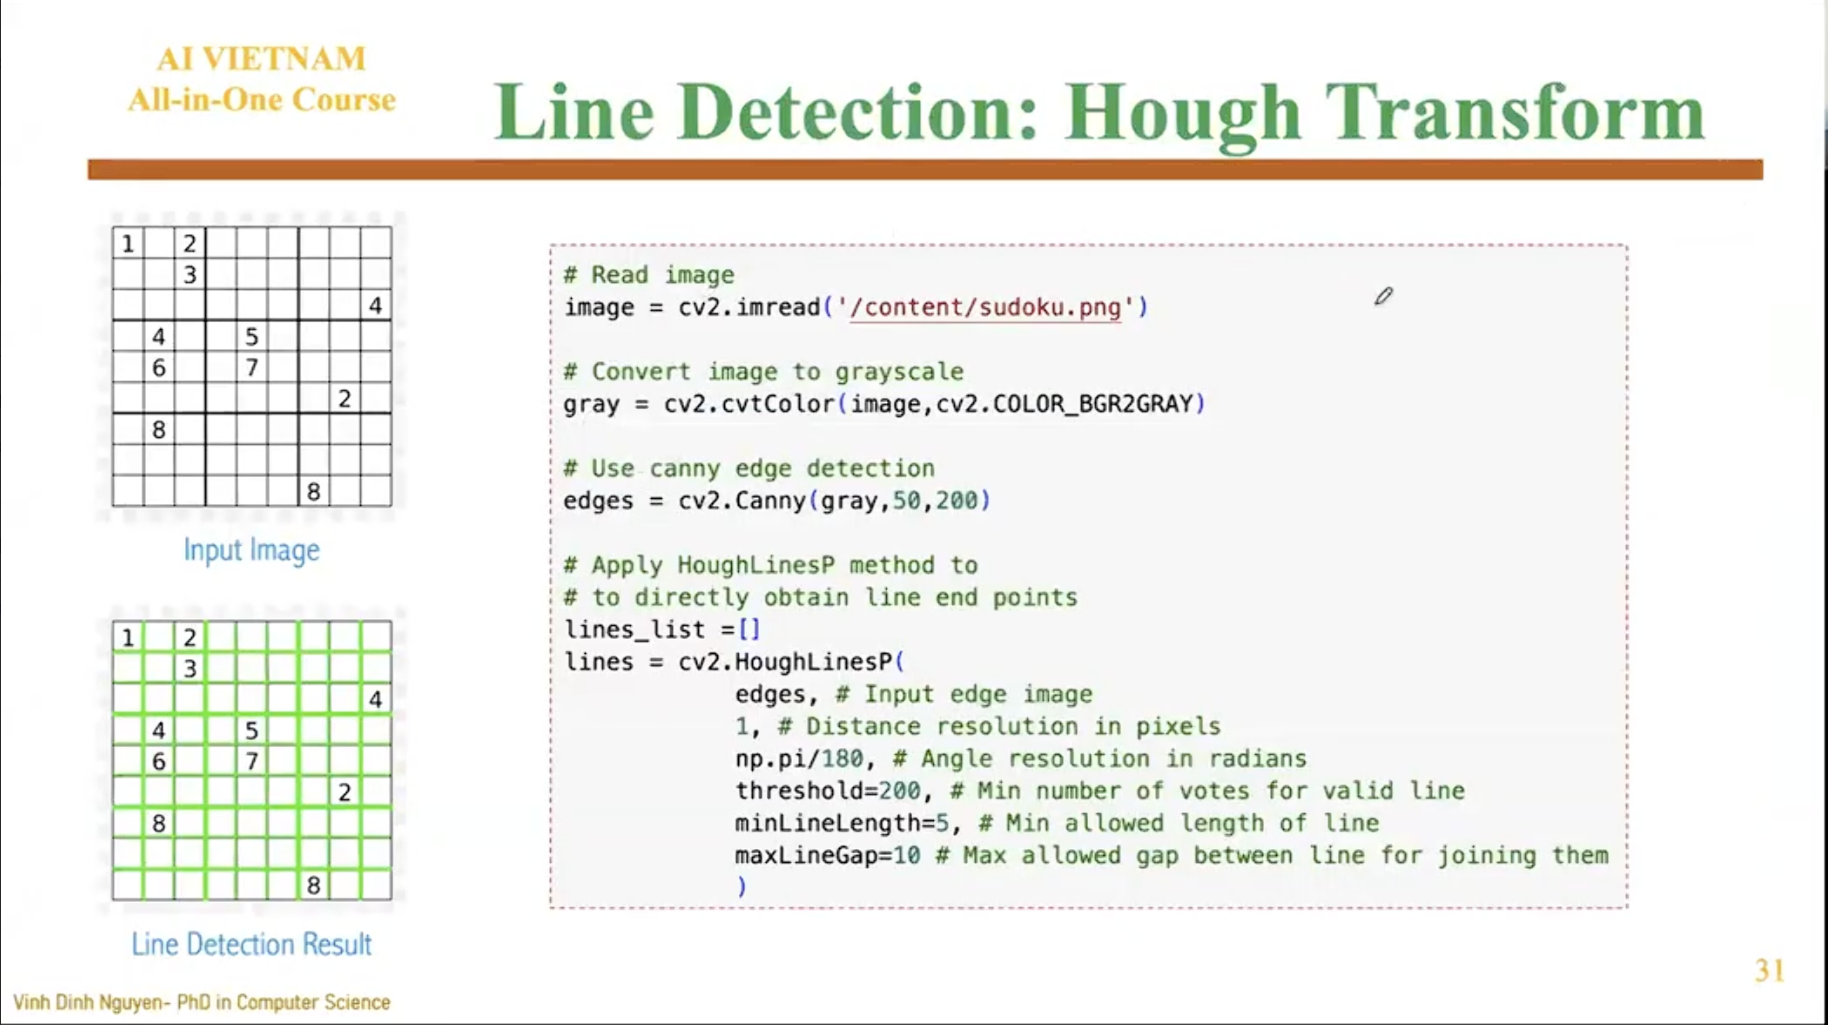

**1. Quy trình phát hiện đường thẳng trong đoạn code**

- Bước 1: Tiền xử lý (Đọc và chuyển sang ảnh xám)
    - image = cv2.imread(...): Đọc bức ảnh Sudoku đầu vào.

    - gray = cv2.cvtColor(...): Chuyển ảnh màu (hoặc ảnh gốc) sang thang độ xám (Grayscale). Thuật toán không cần thông tin màu sắc để tìm đường thẳng, việc chuyển sang ảnh xám giúp giảm khối lượng tính toán đáng kể.

- Bước 2: Tìm cạnh (Edge Detection bằng Canny)
    - edges = cv2.Canny(gray, 50, 200): Đây là bước bắt buộc. Máy tính không thể tự nhiên tìm đường thẳng trên một bức ảnh đầy đủ chi tiết. Nó dùng thuật toán Canny (mà chúng ta vừa nhắc tới ở câu hỏi trước) để trích xuất ra một bức ảnh nhị phân: nền đen, và các viền/cạnh là các nét vẽ màu trắng.

- Bước 3: Phát hiện đường thẳng (Hough Transform)
    - Chương trình dùng hàm cv2.HoughLinesP() áp dụng lên bức ảnh edges (ảnh đã qua Canny) để tìm ra tọa độ điểm đầu và điểm cuối của các đoạn thẳng. Kết quả chính là các đường màu xanh lá cây đè lên lưới Sudoku ở góc dưới bên trái.

**2. Biến đổi Hough hoạt động như thế nào? (Lý thuyết liên quan)**

Thuật toán Hough không quét mắt qua ảnh để "nhìn" đường thẳng như con người. Thay vào đó, nó dùng hệ tọa độ cực với phương trình:
$\rho = x \cos(\theta) + y \sin(\theta)$

Nói một cách dễ hiểu:
- Hệ thống sẽ lấy từng pixel trắng (pixel cạnh) từ ảnh Canny.

- Nó sẽ "bỏ phiếu" (vote) xem điểm đó có thể thuộc về những đường thẳng nào (với mọi góc nghiêng và khoảng cách có thể).

- Đường thẳng nào nhận được nhiều "phiếu bầu" nhất (tức là có nhiều pixel cùng nằm trên nó) thì máy tính kết luận: "Đó là một đường thẳng thật sự".

**3. Giải thích các tham số chuyên sâu trong hàm HoughLinesP**

Bạn sẽ thấy trong code dùng HoughLinesP thay vì HoughLines. Chữ P viết tắt của Probabilistic (Xác suất). Bản tiêu chuẩn (HoughLines) tốn rất nhiều thời gian và chỉ tìm ra đường thẳng dài vô tận. Bản Xác suất (HoughLinesP) tối ưu hơn nhiều, nó chỉ quét một lượng điểm ngẫu nhiên đủ lớn và trả về các đoạn thẳng có điểm bắt đầu/kết thúc rõ ràng.

Các tham số trong code mang ý nghĩa quyết định thuật toán có hoạt động tốt hay không:
- rho (1) & theta (np.pi/180): Độ phân giải khoảng cách (tính bằng pixel) và góc (tính bằng radian). Thông số này để thiết lập "hộp bỏ phiếu" có chi tiết hay không.

- threshold=200: Ngưỡng bỏ phiếu. Một đường thẳng phải có ít nhất 200 pixel nằm trên đó thì mới được công nhận. Số này càng lớn thì thuật toán càng khắt khe, chỉ lấy những nét rất dài và rõ ràng.

- minLineLength=5: Chiều dài tối thiểu của một đoạn thẳng. Nếu một vệt cạnh ngắn hơn 5 pixel, nó bị loại bỏ (coi như nhiễu).

- maxLineGap=10: Khoảng cách đứt gãy tối đa. Đôi khi một đường thẳng bị đứt đoạn thành 2 khúc. Nếu khoảng cách đứt gãy nhỏ hơn 10 pixel, thuật toán sẽ tự động nối 2 khúc đó lại thành 1 đường liền mạch.



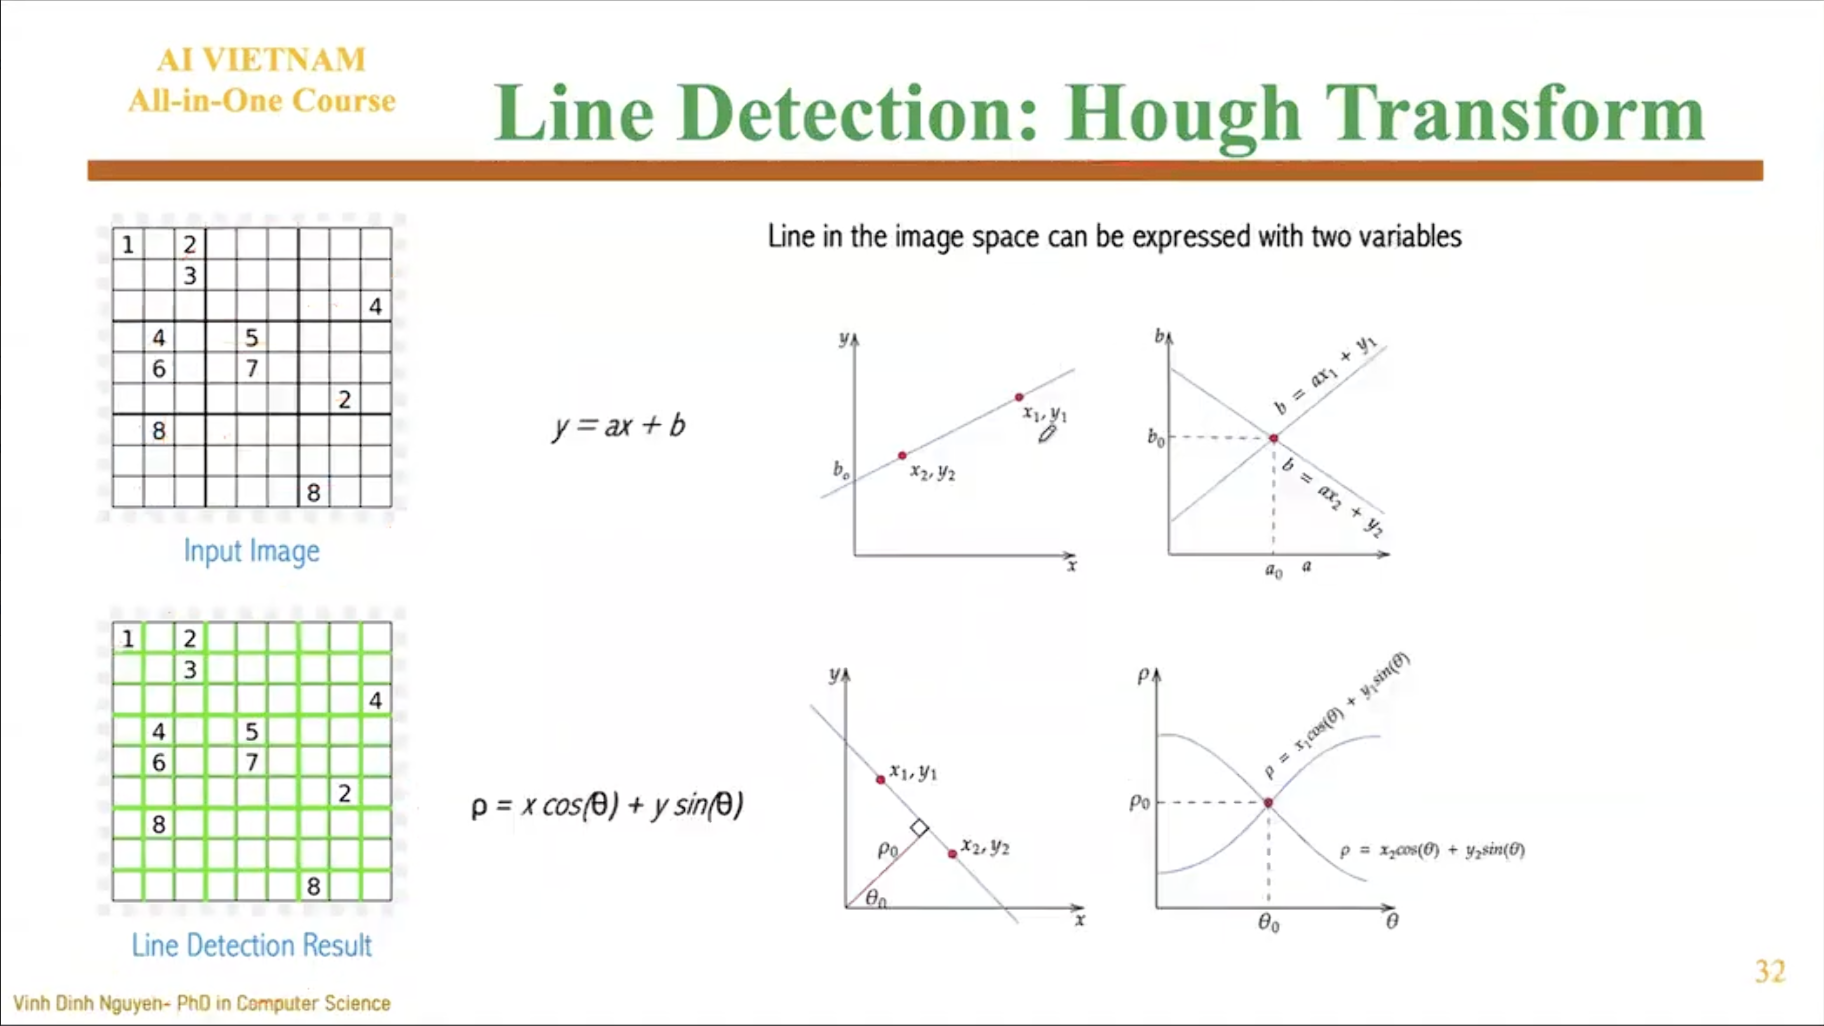